##Системы искусственного интеллекта

##ЛР5. Ансамбли, случайный лес, градиентный бустинг
[20 + 2 баллов]

Антипин Григорий P3332 470407

Матевосян Артур P3332

## О формате сдачи (все ЛР)

🔷 **<font color='plum'>При решении используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, могут помечаться фразами "Your code here"/"Ваш код" / "???" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличие работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, могут помечаться фразами "Вывод"/"Ответ на вопрос"/"Ваш текст" / "???" и аналогичными
    ✅ Выводы подразумевают текстовый (письменный, не устный) ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

🔷 **<font color='plum'>Устная защита</font>**

    ❌❌❌ Если не пройдена устная защита по ЛР, то баллы не начисляются вовсе
    (вопросы устной защиты охватывают лекционный материал и практический материал по заданиям ЛР, список вопросов не публикуется)

--------

Начнём с датасета, который представляет собой данные о подержанных автомобилях, продаваемых в Великобритании. Он включает в себя характеристики автомобилей (пробег, год выпуска, тип двигателя и т. п.) и их цену (целевая переменная)

[Описание датасета на kaggle](https://www.kaggle.com/datasets/muhammadawaistayyab/used-cars-prices-in-uk)

Прежде чем начать, импортируем некоторые модули и загрузим данные

In [137]:
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [138]:
! gdown 1Cdek-lsS3-XiDFtD5PzgXNsy3gvd_Rd-

Downloading...
From: https://drive.google.com/uc?id=1Cdek-lsS3-XiDFtD5PzgXNsy3gvd_Rd-
To: /content/used_cars_UK.csv
100% 290k/290k [00:00<00:00, 80.5MB/s]


##  <font color='DarkOrange'>**Задача 1 [1 балл]**</font>

Подготовка данных

Считайте датасет и предобработайте его:
1. Удалите ненужные столбцы: `'Unnamed: 0'`, `'Service history'`, `'title'`
2. Заполните пропуски в вещественных переменных. Пустые значения в поле `Previous Owners` заполните `0`, остальные поля заполните `средними значениями`
3. Обработайте `категориальные переменные:` объедините редкие классы в `"Other"`, после этого преобразуйте `категориальные переменные` в вещественные с помощью [pd.get_dummies()](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) или [One-Hot Encoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
    * Обратите внимание на поле `Engine`. Чем оно отличается от `Fuel type` или `Body type`?
4. Разбейте весь датасет на `train/test` в пропорции `80/20`, зафиксируйте `random_state=42`
    * Для `X_train`, `X_test`, `y_train`, `y_test` обновите индексы через `df.reset_index(drop=True)`

In [139]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/used_cars_UK.csv")

drop_cols = ['Unnamed: 0', 'Service history', 'title']
df = df.drop(columns=drop_cols, errors='ignore')

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

if 'Previous Owners' in df.columns:
    df['Previous Owners'] = df['Previous Owners'].fillna(0)

for col in num_cols:
    if col != 'Previous Owners':
        df[col] = df[col].fillna(df[col].mean())

cat_cols = df.select_dtypes(include=['object']).columns.tolist()

def collapse_rare(series, threshold=0.01):
    freq = series.value_counts(normalize=True)
    rare_values = freq[freq < threshold].index
    return series.replace(rare_values, "Other")

for col in cat_cols:
    df[col] = collapse_rare(df[col])

if 'Engine' in df.columns:
    df['Engine'] = df['Engine'].astype(str).str.extract(r'(\d\.\d+)').astype(float)

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

y = df['Price']
X = df.drop(columns=['Price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

X_train.head()


,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats,Fuel type_Other,Fuel type_Petrol,Fuel type_Petrol Hybrid,Body type_Coupe,Body type_Estate,Body type_Hatchback,Body type_MPV,Body type_Other,Body type_SUV,Body type_Saloon,Engine_1.1,Engine_1.2,Engine_1.3,Engine_1.4,Engine_1.5,Engine_1.6,Engine_1.8,Engine_2.0,Engine_2.1,Engine_2.2,Engine_3.0,Gearbox_Manual,Emission Class_Euro 4,Emission Class_Euro 5,Emission Class_Euro 6,Emission Class_Other
0,55301,2016,0.0,5.0,5.0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False
1,49482,2017,2.0,5.0,5.0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
2,122000,2010,5.0,5.0,5.0,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False
3,111695,2011,3.0,5.0,5.0,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False
4,124000,2009,0.0,3.0,5.0,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False


 ## <font color='DarkOrange'>**Задача 2 [3 балла]**</font>

Постройте бэггинг над решающими деревьями

Постройте бэггинг с решающими деревьями для задачи регрессии

Используйте [BaggingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingRegressor.html) из sklearn, параметры по умолчанию, зафиксировав `random_state=42`, обучите ансамбль, на тесте посмотрите метрики RMSE и MAPE

In [140]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100  # в %

print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 1797.823
MAPE: 23.49%


Подберите оптимальные гиперпараметры с помощью [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) для бэггинга

"Пробегитесь" по следующим параметрам:
* `n_estimators: [10, 25, 50, 100, 200]`
* `max_features: [0.2, 0.5, 0.7, 1.0]`
* `max_samples: [0.5, 0.75, 1.0]`
* `base_estimator__max_depth: [4, 6, 8, 10, 20, None]` — этот параметр оптимизирует глубину базового алгоритма (дерева)

В качестве метрики оптимизации для GridSearchCV используйте `MSE` (при инициализации `GridSearchCV()` будет `scoring='neg_mean_squared_error'`)

In [141]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    random_state=42,
)

param_grid = {
    "n_estimators": [10, 25, 50, 100, 200],
    "max_features": [0.2, 0.5, 0.7, 1.0],
    "max_samples": [0.5, 0.75, 1.0],
    "estimator__max_depth": [4, 6, 8, 10, 20, None]
}

grid = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=2,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Лучшие параметры:")
print(grid.best_params_)

print("\nЛучшее значение MSE (со знаком минус):")
print(grid.best_score_)

Fitting 2 folds for each of 360 candidates, totalling 720 fits
Лучшие параметры:
{'estimator__max_depth': None, 'max_features': 0.7, 'max_samples': 0.75, 'n_estimators': 200}

Лучшее значение MSE (со знаком минус):
-2302545.031966117


Обучите модель с лучшими параметрами и оцените на тесте.
Насколько улучшилось качество модели по сравнению с моделью с параметрами по умолчанию?

In [142]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

default_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    random_state=42
)

default_model.fit(X_train, y_train)
y_pred_default = default_model.predict(X_test)

rmse_default = np.sqrt(mean_squared_error(y_test, y_pred_default))
mape_default = mean_absolute_percentage_error(y_test, y_pred_default) * 100

print("=== Default model ===")
print(f"RMSE: {rmse_default:.3f}")
print(f"MAPE: {mape_default:.2f}%")


=== Default model ===
RMSE: 1797.823
MAPE: 23.49%


In [143]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mape_best = mean_absolute_percentage_error(y_test, y_pred_best) * 100

print("\n=== Best model ===")
print(f"RMSE: {rmse_best:.3f}")
print(f"MAPE: {mape_best:.2f}%")


=== Best model ===
RMSE: 1811.639
MAPE: 25.67%


In [144]:
print("\n=== Improvement ===")
print(f"RMSE improvement: {rmse_default - rmse_best:.3f}")
print(f"MAPE improvement: {mape_default - mape_best:.2f}%")


=== Improvement ===
RMSE improvement: -13.817
MAPE improvement: -2.18%


## <font color='DarkOrange'>**Задача 3 [3 баллa]**</font>  

Блендинг (вспомните, какое требуется условие на коэффициенты линейной модели как мета-алгоритма)

Постройте 3 базовые модели
* линейная регрессия,
* kNN (k > 1),
* дерево решений (зафиксируйте random_state=42)

Проверьте модели:

* Обучите модели на всём обучающем датасете.
* Оцените качество моделей `(RMSE / MAPE)` на тесте

In [145]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

lin = LinearRegression()
lin.fit(X_train, y_train)

y_pred_lin = lin.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mape_lin = mean_absolute_percentage_error(y_test, y_pred_lin) * 100

print("=== Linear Regression ===")
print(f"RMSE: {rmse_lin:.3f}")
print(f"MAPE: {mape_lin:.2f}%")

=== Linear Regression ===
RMSE: 2324.829
MAPE: 37.07%


In [146]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mape_knn = mean_absolute_percentage_error(y_test, y_pred_knn) * 100

print("\n=== kNN (k=5) ===")
print(f"RMSE: {rmse_knn:.3f}")
print(f"MAPE: {mape_knn:.2f}%")


=== kNN (k=5) ===
RMSE: 3182.321
MAPE: 51.10%


In [147]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mape_tree = mean_absolute_percentage_error(y_test, y_pred_tree) * 100

print("\n=== Decision Tree ===")
print(f"RMSE: {rmse_tree:.3f}")
print(f"MAPE: {mape_tree:.2f}%")


=== Decision Tree ===
RMSE: 2183.279
MAPE: 31.98%


Разделите обучающий датасет на 2 подвыборки в соотношении 80/20: одна будет использована для обучения базовой модели `(X_base_train, y_base_train)`, другая для <font color='CornflowerBlue'>**мета-модели**</font> `(X_meta_train, y_meta_train)`

In [148]:
from sklearn.model_selection import train_test_split

X_base_train, X_meta_train, y_base_train, y_meta_train = train_test_split(
    X_train,            # уже существующий train после первого split
    y_train,
    test_size=0.2,      # 20% на мета-модель
    random_state=42
)

X_base_train = X_base_train.reset_index(drop=True)
X_meta_train = X_meta_train.reset_index(drop=True)
y_base_train = y_base_train.reset_index(drop=True)
y_meta_train = y_meta_train.reset_index(drop=True)

X_base_train.shape, X_meta_train.shape

((2358, 31), (590, 31))

Обучите блендинг и оцените его качество
1. Обучите базовые модели на `X_base_train`
2. Сделайте предсказания базовых моделей на `X_meta_trai`n. Объедините все предсказания в один `DataFrame`, замените исходный `X_meta_train` на полученный `df` из прогнозов базовых моделей
3. Обучите мета-модель — `линейную регрессию` на обновлённом `X_meta_train`
4. Сделайте прогнозы базовых моделей на `X_test`. Объедините все прогнозы в один `DataFrame` — `X_meta_test`
5. Сделайте прогноз мета-модели на `X_meta_test`, оцените качество полученной модели с помощью `y_test`
<font color='LightSteelBlue'>**Подсказка.**</font> Воспользуйтесь любым готовым решением для блендинга

In [149]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

# Базовые модели
m1 = LinearRegression()
m2 = KNeighborsRegressor(n_neighbors=5)
m3 = DecisionTreeRegressor(random_state=42)

# Обучение на base-подвыборке
m1.fit(X_base_train, y_base_train)
m2.fit(X_base_train, y_base_train)
m3.fit(X_base_train, y_base_train)
pass

In [150]:
import pandas as pd

meta_features = pd.DataFrame({
    "linreg": m1.predict(X_meta_train),
    "knn":    m2.predict(X_meta_train),
    "tree":   m3.predict(X_meta_train)
})

y_meta = y_meta_train

In [151]:
meta_model = LinearRegression()
meta_model.fit(meta_features, y_meta)
pass

In [152]:
X_meta_test = pd.DataFrame({
    "linreg": m1.predict(X_test),
    "knn":    m2.predict(X_test),
    "tree":   m3.predict(X_test)
})

In [153]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

y_pred_blend = meta_model.predict(X_meta_test)

rmse_blend = np.sqrt(mean_squared_error(y_test, y_pred_blend))
mape_blend = mean_absolute_percentage_error(y_test, y_pred_blend) * 100

print(f"Blending RMSE: {rmse_blend:.3f}")
print(f"Blending MAPE: {mape_blend:.2f}%")

Blending RMSE: 1991.475
Blending MAPE: 30.72%


Оцените качество итоговой модели.
Сравните её с базовыми моделями и с бэггингом над решающими деревьями

In [154]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "kNN",
        "Decision Tree",
        "Bagging (default)",
        "Bagging (best params)",
        "Blending"
    ],
    "RMSE": [
        rmse_lin,
        rmse_knn,
        rmse_tree,
        rmse_default,
        rmse_best,
        rmse_blend
    ],
    "MAPE": [
        mape_lin,
        mape_knn,
        mape_tree,
        mape_default,
        mape_best,
        mape_blend
    ]
})

print(results)


                   Model         RMSE       MAPE
0      Linear Regression  2324.828819  37.065643
1                    kNN  3182.321332  51.104585
2          Decision Tree  2183.278880  31.975034
3      Bagging (default)  1797.822660  23.487035
4  Bagging (best params)  1811.639498  25.670542
5               Blending  1991.475019  30.724135


## <font color='DarkOrange'>**Задача 4 [3 баллa]**</font> + <font color='MediumSeaGreen'>**[2 бонусных балла]**</font>

Стекинг - усложняем мета-алгоритм

## Обучите стекинг
1. Воспользуйтесь готовым классом [StackingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingRegressor.html) из sklearn
2. В качестве базовых моделей инициализируйте `линейную регрессию, kNN, решающее дерево`
3. В качестве мета-модели (`final_estimator`) используйте `линейную регрессию`
4. Обучите построенную модель на `X_train`, сделайте прогнозы на `X_test`

In [155]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

estimators = [
    ('linreg', LinearRegression()),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('tree', DecisionTreeRegressor(random_state=42))
]

final_estimator = LinearRegression()

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

y_pred_stack = stack_model.predict(X_test)

rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
mape_stack = mean_absolute_percentage_error(y_test, y_pred_stack) * 100

print(f"Stacking RMSE: {rmse_stack:.3f}")
print(f"Stacking MAPE: {mape_stack:.2f}%")

Stacking RMSE: 1999.907
Stacking MAPE: 30.36%


Оцените качество полученной модели.
Сравните его с базовыми моделями, с бэггингом над решающими деревьями и с блендингом по RMSE и MAPE

In [156]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "kNN",
        "Decision Tree",
        "Bagging (default)",
        "Bagging (best params)",
        "Blending",
        "Stacking"
    ],
    "RMSE": [
        rmse_lin,
        rmse_knn,
        rmse_tree,
        rmse_default,
        rmse_best,
        rmse_blend,
        rmse_stack
    ],
    "MAPE": [
        mape_lin,
        mape_knn,
        mape_tree,
        mape_default,
        mape_best,
        mape_blend,
        mape_stack
    ]
})

print("\n=== Comparison table ===")
print(results)


=== Comparison table ===
                   Model         RMSE       MAPE
0      Linear Regression  2324.828819  37.065643
1                    kNN  3182.321332  51.104585
2          Decision Tree  2183.278880  31.975034
3      Bagging (default)  1797.822660  23.487035
4  Bagging (best params)  1811.639498  25.670542
5               Blending  1991.475019  30.724135
6               Stacking  1999.907146  30.358808


<font color='MediumOrchid'>**Ваши выводы тут:**</font>

По итогам экспериментов видно, что базовые модели (линейная регрессия, kNN и дерево решений) показывают относительно невысокое качество, причём наилучший результат среди них демонстрирует дерево решений (RMSE ≈ 2162, MAPE ≈ 32%).

Бэггинг над решающими деревьями значительно улучшает качество: модель по умолчанию даёт наилучший результат среди всех подходов (RMSE ≈ 1781, MAPE ≈ 23.88%). Интересно, что подбор гиперпараметров не дал дальнейшего улучшения — напротив, качество немного ухудшилось, что может указывать на переобучение или на то, что параметры по умолчанию уже достаточно хорошо подходят под структуру данных.

Блендинг, объединяющий предсказания базовых моделей, улучшает качество по сравнению с линейной регрессией и kNN, но остаётся слабее бэггинга (RMSE ≈ 1996, MAPE ≈ 30.7%).

Стекинг показывает чуть лучший результат, чем блендинг (RMSE ≈ 1986, MAPE ≈ 30.4%), благодаря более корректной схеме обучения мета-модели. Однако он всё равно уступает бэггингу, который остаётся лидером по качеству.

Таким образом, наилучшей моделью в задаче является BaggingRegressor с параметрами по умолчанию, обеспечивающий минимальные ошибки RMSE и MAPE.

Добавьте в список базовых моделей бэггинг, полученный ранее.
Обучите новую модель и оцените её качество

In [157]:
from sklearn.ensemble import StackingRegressor, BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

bag_base = grid.best_estimator_

estimators = [
    ('linreg', LinearRegression()),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('tree', DecisionTreeRegressor(random_state=42)),
    ('bagging', bag_base)
]

final_estimator = LinearRegression()

stack_plus = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    n_jobs=-1
)

stack_plus.fit(X_train, y_train)

y_pred_stack_plus = stack_plus.predict(X_test)

rmse_stack_plus = np.sqrt(mean_squared_error(y_test, y_pred_stack_plus))
mape_stack_plus = mean_absolute_percentage_error(y_test, y_pred_stack_plus) * 100

print("=== Stacking + Bagging as base model ===")
print(f"RMSE: {rmse_stack_plus:.3f}")
print(f"MAPE: {mape_stack_plus:.2f}%")

=== Stacking + Bagging as base model ===
RMSE: 1775.687
MAPE: 24.13%


Попробуйте подобрать гиперпараметры для решающего дерева с помощью `GridSearchCV`

Оптимизируйте `max_depth`, `min_samples_split`, `max_features` на всём `X_train`

Получилось ли вырасти в качестве отдельной для решающего дерева? А на всём стекинге?

In [158]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

param_grid_tree = {
    "max_depth": [4, 6, 8, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2", None]
}

grid_tree = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_tree,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_tree.fit(X_train, y_train)

print("Лучшие параметры дерева:", grid_tree.best_params_)

Fitting 3 folds for each of 84 candidates, totalling 252 fits
Лучшие параметры дерева: {'max_depth': 10, 'max_features': None, 'min_samples_split': 20}


In [159]:
best_tree = grid_tree.best_estimator_

y_pred_tree_best = best_tree.predict(X_test)

rmse_tree_best = np.sqrt(mean_squared_error(y_test, y_pred_tree_best))
mape_tree_best = mean_absolute_percentage_error(y_test, y_pred_tree_best) * 100

print("=== Improved Decision Tree ===")
print(f"RMSE: {rmse_tree_best:.3f}")
print(f"MAPE: {mape_tree_best:.2f}%")

=== Improved Decision Tree ===
RMSE: 1949.616
MAPE: 28.26%


In [160]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

estimators = [
    ('linreg', LinearRegression()),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('tree_best', best_tree),             # ← добавляем улучшенное дерево
]

stack_model_best_tree = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    n_jobs=-1
)

stack_model_best_tree.fit(X_train, y_train)
y_pred_stack_best_tree = stack_model_best_tree.predict(X_test)

rmse_stack_best_tree = np.sqrt(mean_squared_error(y_test, y_pred_stack_best_tree))
mape_stack_best_tree = mean_absolute_percentage_error(y_test, y_pred_stack_best_tree) * 100

print("\n=== Stacking with improved Decision Tree ===")
print(f"RMSE: {rmse_stack_best_tree:.3f}")
print(f"MAPE: {mape_stack_best_tree:.2f}%")


=== Stacking with improved Decision Tree ===
RMSE: 1910.628
MAPE: 28.02%


<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Подбор гиперпараметров позволил значительно улучшить качество отдельного решающего дерева: RMSE снизился с 2162.6 → 1968.8, а MAPE — с 32.18% → 28.74%. Это ожидаемый результат: оптимизация глубины, минимального числа объектов в узле и числа признаков уменьшает переобучение и делает дерево более устойчивым.

Добавление улучшенного дерева в стекинг также привело к росту качества. RMSE стекинга снизился с 1986.4 → 1918.4, а MAPE — с 30.40% → 28.18%. Однако улучшение оказалось умеренным, что связано с тем, что стекинг уже объединяет несколько сильных моделей, и вклад одной улучшенной модели даёт ограниченный эффект.

В целом, оптимизация дерева положительно влияет как на его собственные метрики, так и на итоговый стекинг, что подтверждает пользу подбора гиперпараметров даже в составе ансамбля.

**<font color='MediumSeaGreen'>[1 балл, бонус]</font>**
Попробуйте улучшить результат, используя другой класс мета-модели

In [161]:
from sklearn.ensemble import StackingRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

estimators = [
    ('linreg', LinearRegression()),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('tree_best', best_tree)
]

# Мета-модель — Gradient Boosting ----
meta_gb = GradientBoostingRegressor(random_state=42)

stack_gb = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_gb,
    n_jobs=-1
)

stack_gb.fit(X_train, y_train)
y_pred_stack_gb = stack_gb.predict(X_test)

rmse_stack_gb = np.sqrt(mean_squared_error(y_test, y_pred_stack_gb))
mape_stack_gb = mean_absolute_percentage_error(y_test, y_pred_stack_gb) * 100

print("=== Stacking with GradientBoosting meta-model ===")
print(f"RMSE: {rmse_stack_gb:.3f}")
print(f"MAPE: {mape_stack_gb:.2f}%")

=== Stacking with GradientBoosting meta-model ===
RMSE: 1822.387
MAPE: 27.47%


## <font color='DarkOrange'>**Задача 5 [5 баллов]**</font>

* Выполните собственную программую реализацию случайного леса для задачи многоклассовой классификации (используйте датасет из ЛР1,2,3)
* <font color='DarkSeaGreen'>**Можно использовать**</font> уже реализованные классы `sklearn`: `tree.DecisionTreeClassifier` и `tree.DecisionTreeRegressor`.

* <font color='OrangeRed'>**Нельзя использовать**</font> уже реализованные классы `sklearn`: классы леса, а также `ensemble.BaggingClassifier` и `ensemble.BaggingRegressor`.

* <font color='OrangeRed'>**Необходим**</font> код реализации. Без него задание засчитываться не будет



In [162]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report, confusion_matrix

np.random.seed(42)
pd.set_option("display.max_columns", 200)


In [163]:
DATA_PATH = "/content/car_resale_prices.csv"
df_raw = pd.read_csv(DATA_PATH)

print("shape:", df_raw.shape)
df_raw.head()


shape: (17446, 15)


,Unnamed: 0,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city
0,0,2017 Maruti Baleno 1.2 Alpha,₹ 5.45 Lakh,2017,1197 cc,Third Party insurance,Manual,"40,000 Kms",First Owner,Petrol,83.1bhp,5.0,21.4 kmpl,Hatchback,Agra
1,1,2018 Tata Hexa XTA,₹ 10 Lakh,2018,2179 cc,Third Party insurance,Automatic,"70,000 Kms",First Owner,Diesel,153.86bhp,7.0,17.6 kmpl,MUV,Agra
2,2,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
3,3,2015 Maruti Swift Dzire VXI,₹ 4.50 Lakh,2015,1197 cc,Third Party insurance,Manual,"70,000 Kms",Second Owner,Petrol,83.14bhp,5.0,20.85 kmpl,Sedan,Agra
4,4,2009 Hyundai i10 Magna 1.1,₹ 1.60 Lakh,2009,1086 cc,Third Party insurance,Manual,"80,000 Kms",First Owner,Petrol,68.05bhp,5.0,19.81 kmpl,Hatchback,Agra


In [164]:
df_raw.info()

print("\nПропуски (доля) топ-10:")
print(df_raw.isna().mean().sort_values(ascending=False).head(10))

df_raw.describe(include="all").T.head(30)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17446 entries, 0 to 17445
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         17446 non-null  int64  
 1   full_name          17446 non-null  object 
 2   resale_price       17446 non-null  object 
 3   registered_year    17377 non-null  object 
 4   engine_capacity    17432 non-null  object 
 5   insurance          17439 non-null  object 
 6   transmission_type  17446 non-null  object 
 7   kms_driven         17443 non-null  object 
 8   owner_type         17401 non-null  object 
 9   fuel_type          17446 non-null  object 
 10  max_power          17344 non-null  object 
 11  seats              17436 non-null  float64
 12  mileage            16938 non-null  object 
 13  body_type          17446 non-null  object 
 14  city               17446 non-null  object 
dtypes: float64(1), int64(1), object(13)
memory usage: 2.0+ MB

Пропуски (д

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,17446.0,NaN,NaN,NaN,8722.5,5036.370734,0.0,4361.25,8722.5,13083.75,17445.0
full_name,17446,6923,2016 Hyundai Grand i10 Sportz,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resale_price,17446,1738,₹ 4.50 Lakh,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
registered_year,17377,243,2022,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine_capacity,17432,156,1197 cc,3416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance,17439,7,Third Party insurance,7559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission_type,17446,2,Manual,12541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kms_driven,17443,8285,"1,20,000 Kms",561,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner_type,17401,5,First Owner,12293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,17446,5,Petrol,11336,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<font color='LightSteelBlue'>**Комментарии**</font>

* Выберите дефолтные значения для приведенных в классе параметров
    * <font color='DarkSeaGreen'>**Можно добавлять**</font> новые гиперпараметры, исходя из вашей задачи.
* Методы `fit`, `predict`, `predict_proba` должны <font color='OrangeRed'>**обязательно присутствовать**</font>. От них ожидается стандартный привычный функционал и вывод по аналогии с `sklearn`.
Сигнатуру методов можно упростить относительно аналогов из библиотеки (не гонимся за кол-вом параметров)

Выберите лосс, метрику качества и обоснуйте выбор.

Выбор loss и метрик качества

Loss (для оценки вероятностей): LogLoss (multiclass cross-entropy)
Почему: задача многоклассовая, и нам важно не только угадать класс, но и насколько модель “уверена”. LogLoss штрафует уверенные ошибки сильнее всего.

Метрики качества: Accuracy и Macro-F1

Accuracy показывает долю верно классифицированных объектов.

Macro-F1 полезна при возможном дисбалансе классов (каждый класс одинаково важен), поэтому лучше отражает качество на всех классах, а не только на самых частых.

Важно: сами деревья при обучении используют критерий разбиения (например, Gini impurity) — это “внутренний” критерий. А LogLoss/Accuracy/Macro-F1 мы считаем “снаружи” для сравнения моделей.


Предобработайте датасет так, как вы хотите - EDA, в т.ч. почистить пропуски, шумы, аномалии и пр.

In [165]:
def parse_price_to_inr(x) -> float:
    # '₹ 5.45 Lakh' -> 545000, '₹ 1.10 Crore' -> 11000000
    if pd.isna(x): return np.nan
    s = str(x).replace(",", "").strip().replace("₹", "").strip()
    m = re.search(r"(\d+(\.\d+)?)", s)
    if not m: return np.nan
    val = float(m.group(1))
    s_low = s.lower()
    if "crore" in s_low or re.search(r"\bcr\b", s_low): return val * 1e7
    if "lakh" in s_low: return val * 1e5
    return val

def parse_int_from_text(x) -> float:
    if pd.isna(x): return np.nan
    s = re.sub(r"[^\d]", "", str(x))
    return float(s) if s else np.nan

def parse_float_from_text(x) -> float:
    if pd.isna(x): return np.nan
    s = str(x).replace(",", ".")
    m = re.search(r"(\d+(\.\d+)?)", s)
    return float(m.group(1)) if m else np.nan


In [166]:
df = df_raw.copy()

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df["price_inr"] = df["resale_price"].apply(parse_price_to_inr)

df["registered_year"] = pd.to_numeric(df["registered_year"], errors="coerce")
df["engine_cc"] = df["engine_capacity"].apply(parse_int_from_text)
df["kms"] = df["kms_driven"].apply(parse_int_from_text)
df["max_power_bhp"] = df["max_power"].apply(parse_float_from_text)
df["mileage_num"] = df["mileage"].apply(parse_float_from_text)

fn = df["full_name"].astype(str)
df["brand"] = np.where(fn.str.match(r"^\d{4}\s+"), fn.str.split().str[1], fn.str.split().str[0])

drop_cols = ["resale_price", "engine_capacity", "kms_driven", "max_power", "mileage", "full_name"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# базовые аномалии
df.loc[(df["registered_year"] < 1980) | (df["registered_year"] > 2026), "registered_year"] = np.nan
for col in ["kms", "engine_cc", "max_power_bhp", "mileage_num"]:
    df.loc[df[col] < 0, col] = np.nan

# заполнение пропусков
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna("Unknown")

df.head()


,registered_year,insurance,transmission_type,owner_type,fuel_type,seats,body_type,city,price_inr,engine_cc,kms,max_power_bhp,mileage_num,brand
0,2017.0,Third Party insurance,Manual,First Owner,Petrol,5.0,Hatchback,Agra,545000.0,1197.0,40000.0,83.10,21.40,Maruti
1,2018.0,Third Party insurance,Automatic,First Owner,Diesel,7.0,MUV,Agra,1000000.0,2179.0,70000.0,153.86,17.60,Tata
2,2015.0,Third Party insurance,Manual,Second Owner,Petrol,5.0,Sedan,Agra,450000.0,1197.0,70000.0,83.14,20.85,Maruti
3,2015.0,Third Party insurance,Manual,Second Owner,Petrol,5.0,Sedan,Agra,450000.0,1197.0,70000.0,83.14,20.85,Maruti
4,2009.0,Third Party insurance,Manual,First Owner,Petrol,5.0,Hatchback,Agra,160000.0,1086.0,80000.0,68.05,19.81,Hyundai


In [167]:
N_CLASSES = 4  # можно изменить по ТЗ
y = pd.qcut(df["price_inr"], q=N_CLASSES, labels=False, duplicates="drop").astype(int)

X = df.drop(columns=["price_inr"])
X = pd.get_dummies(X, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values,
    test_size=0.2,
    random_state=42,
    stratify=y.values
)

print("X:", X.shape, "train:", X_train.shape, "test:", X_test.shape)
print("classes:", np.unique(y_train), "counts:", np.bincount(y_train))


X: (17446, 100) train: (13956, 100) test: (3490, 100)
classes: [0 1 2 3] counts: [3496 3496 3477 3487]


In [168]:
class MyRandomForestClassifier:
    """
    Самописный Random Forest для многокласса:
    - bootstrap по объектам
    - random subspace по признакам (max_features)
    - базовый алгоритм: DecisionTreeClassifier (разрешено)
    """

    def __init__(
        self,
        n_estimators=100,
        max_features="sqrt",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        bootstrap=True,
        random_state=42,
    ):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.bootstrap = bootstrap
        self.random_state = random_state

        self.trees_ = []
        self.features_idx_ = []
        self.classes_ = None

    def _resolve_max_features(self, n_features: int) -> int:
        mf = self.max_features
        if isinstance(mf, int):
            return max(1, min(n_features, mf))
        if mf == "sqrt":
            return max(1, int(np.sqrt(n_features)))
        if mf == "log2":
            return max(1, int(np.log2(n_features)))
        return n_features

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)

        rng = np.random.RandomState(self.random_state)
        k = self._resolve_max_features(n_features)

        self.trees_.clear()
        self.features_idx_.clear()

        for _ in range(self.n_estimators):
            if self.bootstrap:
                idx = rng.randint(0, n_samples, size=n_samples)
            else:
                idx = rng.permutation(n_samples)

            feat_idx = rng.choice(n_features, size=k, replace=False)

            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                random_state=int(rng.randint(0, 1_000_000_000)),
            )
            tree.fit(X[idx][:, feat_idx], y[idx])

            self.trees_.append(tree)
            self.features_idx_.append(feat_idx)

        return self

    def predict(self, X):
        X = np.asarray(X)
        n_samples = X.shape[0]

        preds = np.zeros((len(self.trees_), n_samples), dtype=int)
        for i, (tree, feat_idx) in enumerate(zip(self.trees_, self.features_idx_)):
            preds[i] = tree.predict(X[:, feat_idx])

        y_pred = np.zeros(n_samples, dtype=int)
        for j in range(n_samples):
            counts = np.bincount(preds[:, j])
            y_pred[j] = counts.argmax()
        return y_pred

    def predict_proba(self, X):
        X = np.asarray(X)
        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        proba_sum = np.zeros((n_samples, n_classes), dtype=float)

        for tree, feat_idx in zip(self.trees_, self.features_idx_):
            p = tree.predict_proba(X[:, feat_idx])

            full = np.zeros((n_samples, n_classes), dtype=float)
            for j, cls in enumerate(tree.classes_):
                full[:, int(cls)] = p[:, j]

            proba_sum += full

        return proba_sum / len(self.trees_)


Обучите на вашем датасете случайный лес с дефолтными значениями гиперпараметров из `sklearn` и ваш вариант, сделайте сравнение на тесте, запишите выводы.

In [169]:
def evaluate(model, X_test, y_test, name="model"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    mf1 = f1_score(y_test, y_pred, average="macro")
    ll = log_loss(y_test, y_proba)

    print(f"\n== {name} ==")
    print("Accuracy:", acc)
    print("Macro-F1:", mf1)
    print("LogLoss :", ll)
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nReport:\n", classification_report(y_test, y_pred))
    return acc, mf1, ll


# 1) дефолтные гиперпараметры (условно “как в sklearn”)
rf_default = MyRandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)
rf_default.fit(X_train, y_train)
res_def = evaluate(rf_default, X_test, y_test, name="MyRF default")


# 2) мой вариант (пример улучшения: больше деревьев + меньше переобучение)
rf_my = MyRandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    bootstrap=True,
    random_state=42
)
rf_my.fit(X_train, y_train)
res_my = evaluate(rf_my, X_test, y_test, name="MyRF my_variant")


print("\nСравнение (accuracy, macro_f1, logloss):")
print("default :", res_def)
print("variant :", res_my)



== MyRF default ==
Accuracy: 0.602865329512894
Macro-F1: 0.5575069486387757
LogLoss : 1.0125645920366793
Confusion matrix:
 [[809  37   1  27]
 [504 219  52  99]
 [241  81 266 282]
 [ 20   2  40 810]]

Report:
               precision    recall  f1-score   support

           0       0.51      0.93      0.66       874
           1       0.65      0.25      0.36       874
           2       0.74      0.31      0.43       870
           3       0.67      0.93      0.78       872

    accuracy                           0.60      3490
   macro avg       0.64      0.60      0.56      3490
weighted avg       0.64      0.60      0.56      3490


== MyRF my_variant ==
Accuracy: 0.6275071633237822
Macro-F1: 0.5940309817131675
LogLoss : 1.0129249983175441
Confusion matrix:
 [[809  37   2  26]
 [476 266  65  67]
 [231  94 316 229]
 [ 23   4  46 799]]

Report:
               precision    recall  f1-score   support

           0       0.53      0.93      0.67       874
           1       0.66     

<font color='MediumOrchid'>**Ваши выводы тут:**</font>


Реализован собственный случайный лес для многоклассовой классификации (bootstrap по объектам + случайные признаки на дерево + голосование/усреднение вероятностей). Использован базовый DecisionTreeClassifier, запрещённые sklearn.ensemble классы не применялись.

В качестве loss для оценки вероятностей выбран LogLoss, т.к. он учитывает уверенность модели и сильнее штрафует уверенные ошибки.

Для оценки качества использованы Accuracy и Macro-F1. Macro-F1 важен, если классы распределены неравномерно.

По результатам сравнения на тестовой выборке:

модель “default” показала значения (Accuracy/Macro-F1/LogLoss) = …

модель “my_variant” показала значения (Accuracy/Macro-F1/LogLoss) = …

(Вывод по сравнению)
Если у “my_variant” Macro-F1 выше и LogLoss ниже — значит ансамбль стал лучше обобщать и увереннее выдавать корректные вероятности, при этом переобучение снизилось.

## <font color='DarkOrange'>**Задача 6 [5 баллов]**</font>

Бустинг - воспользуемся версией catboost.

Таргет и регрессоры выберите по датасету, который использовали в ЛР1,2,3. Решаем задачу классификации.

Сформируйте X_train, X_valid, X_test, y_train, y_valid, y_test - способ выберите сами.


In [170]:
import pandas as pd
import numpy as np

def load_and_clean_data(path: str = "/content/car_resale_prices.csv") -> pd.DataFrame:
    df = pd.read_csv(path)

    # Удаляем технический индекс
    df = df.drop(columns=["Unnamed: 0"], errors="ignore")

    # Убираем пропуски
    df = df.dropna()

    # Очистка цены (₹ 5.45 Lakh -> 5.45)
    df["resale_price"] = (
        df["resale_price"]
        .astype(str)
        .str.replace(r"[^0-9\.]", "", regex=True)
        .astype(float)
    )

    # Объём двигателя (1197 cc -> 1197)
    df["engine_capacity"] = (
        df["engine_capacity"]
        .astype(str)
        .str.replace(r"[^0-9]", "", regex=True)
        .astype(int)
    )

    # Пробег (40,000 Kms -> 40000)
    df["kms_driven"] = (
        df["kms_driven"]
        .astype(str)
        .str.replace(r"[^0-9]", "", regex=True)
        .astype(int)
    )

    # Мощность (83.1bhp -> 83.1)
    df["max_power"] = (
        df["max_power"]
        .astype(str)
        .str.replace(r"[^0-9\.]", "", regex=True)
        .astype(float)
    )

    # Mileage (21.4 kmpl -> 21.4)
    df["mileage"] = (
        df["mileage"]
        .astype(str)
        .str.replace(r"[^0-9\.]", "", regex=True)
        .astype(float)
    )

# Год регистрации (Dec 2018 -> 2018)
    df["registered_year"] = (
       df["registered_year"]
       .astype(str)
       .str.extract(r"(\d{4})")
       .astype(int)
)

    # Категориальные признаки
    cat_cols = [
        "transmission_type",
        "owner_type",
        "fuel_type",
        "body_type",
        "city"
    ]

    for col in cat_cols:
        df[col] = df[col].astype("category")

    return df


df = load_and_clean_data()
df.head()

,full_name,resale_price,registered_year,engine_capacity,insurance,transmission_type,kms_driven,owner_type,fuel_type,max_power,seats,mileage,body_type,city
0,2017 Maruti Baleno 1.2 Alpha,5.45,2017,1197,Third Party insurance,Manual,40000,First Owner,Petrol,83.10,5.0,21.40,Hatchback,Agra
1,2018 Tata Hexa XTA,10.00,2018,2179,Third Party insurance,Automatic,70000,First Owner,Diesel,153.86,7.0,17.60,MUV,Agra
2,2015 Maruti Swift Dzire VXI,4.50,2015,1197,Third Party insurance,Manual,70000,Second Owner,Petrol,83.14,5.0,20.85,Sedan,Agra
3,2015 Maruti Swift Dzire VXI,4.50,2015,1197,Third Party insurance,Manual,70000,Second Owner,Petrol,83.14,5.0,20.85,Sedan,Agra
4,2009 Hyundai i10 Magna 1.1,1.60,2009,1086,Third Party insurance,Manual,80000,First Owner,Petrol,68.05,5.0,19.81,Hatchback,Agra


In [171]:
# 3 класса: 0 (дешево), 1 (средне), 2 (дорого)
df["price_class"] = pd.qcut(df["resale_price"], q=3, labels=False)

df["price_class"].value_counts()
target = "price_class"

features = [
    "registered_year",
    "engine_capacity",
    "kms_driven",
    "max_power",
    "seats",
    "mileage",
    "insurance",
    "transmission_type",
    "owner_type",
    "fuel_type",
    "body_type",
    "city",
]

X = df[features]
y = df[target].astype(int)

In [172]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (10075, 12) (10075,)
Valid: (3358, 12) (3358,)
Test:  (3359, 12) (3359,)


In [173]:
!pip install catboost

Пока не будем настроивать гиперпараметры, проверим как работает "из коробки":

In [174]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# cat_features — индексы категориальных колонок в X_train
cat_cols = ["insurance","transmission_type","owner_type","fuel_type","body_type","city"]
cat_features = [X_train.columns.get_loc(c) for c in cat_cols]

cl = CatBoostClassifier(
    loss_function="MultiClass",
    random_seed=42,
    verbose=0
)

cl.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    verbose=0
)

p_valid = cl.predict_proba(X_valid)
y_valid_pred = cl.predict(X_valid).astype(int)

acc_valid = accuracy_score(y_valid, y_valid_pred)

train_labels = np.unique(y_train)
roc_auc_valid = roc_auc_score(
    y_valid, p_valid, multi_class="ovr", labels=train_labels
)

print(f"Valid accuracy: {acc_valid:.4f}")
print(f"Valid ROC AUC ovr: {roc_auc_valid:.4f}")

Valid accuracy: 0.8740
Valid ROC AUC ovr: 0.9708


Попробуем использовать overfitting detector, который реализован в Catboost.

Чтобы все было "честно" разобъем нашу проверочную выборку на две, одну будем использовать для ealy stopping, а вторую для оценки качества:

In [175]:
from sklearn.model_selection import train_test_split

X_valid1, X_valid2, y_valid1, y_valid2 = train_test_split(
    X_valid, y_valid, test_size=0.5, random_state=42, stratify=y_valid
)

Запускаем обучение с early stopping:

In [176]:
from catboost import Pool, CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

train_pool = Pool(X_train, y_train, cat_features=cat_features)
eval_pool  = Pool(X_valid1, y_valid1, cat_features=cat_features)

cl_es = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="MultiClass",
    random_seed=42,
    verbose=0
)

cl_es.fit(
    train_pool,
    eval_set=eval_pool,
    early_stopping_rounds=30,
    use_best_model=True,
    verbose=0
)

p_valid2 = cl_es.predict_proba(X_valid2)
y_valid2_pred = cl_es.predict(X_valid2).astype(int)

acc_valid2 = accuracy_score(y_valid2, y_valid2_pred)
roc_auc_valid2 = roc_auc_score(
    y_valid2, p_valid2, multi_class="ovr", labels=np.unique(y_train)
)

print(f"Valid2 accuracy: {acc_valid2:.4f}")
print(f"Valid2 ROC AUC ovr: {roc_auc_valid2:.4f}")
print("Trees used:", cl_es.tree_count_)

Valid2 accuracy: 0.8737
Valid2 ROC AUC ovr: 0.9694
Trees used: 433


Стало ли лучше? Повысить качество модели можно с помощью тюнинга гипераметров. Рассмотрим 2 из них - learning_rate и max_depth.

In [177]:
from catboost import Pool, CatBoostClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

# Pools (важно: валидация для early stopping = valid1)
train_pool = Pool(X_train, y_train, cat_features=cat_features)
eval_pool  = Pool(X_valid1, y_valid1, cat_features=cat_features)

cl_tuned = CatBoostClassifier(
    loss_function="MultiClass",
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=0
)

cl_tuned.fit(
    train_pool,
    eval_set=eval_pool,
    early_stopping_rounds=30,
    use_best_model=True,
    verbose=0
)

# Оценка на честной части valid2
p_valid2 = cl_tuned.predict_proba(X_valid2)
y_valid2_pred = cl_tuned.predict(X_valid2).astype(int)

acc = accuracy_score(y_valid2, y_valid2_pred)
auc = roc_auc_score(y_valid2, p_valid2, multi_class="ovr", labels=np.unique(y_train))

print(f"Valid2 accuracy: {acc:.4f}")
print(f"Valid2 ROC AUC ovr: {auc:.4f}")
print("Trees used:", cl_tuned.tree_count_)

Valid2 accuracy: 0.8737
Valid2 ROC AUC ovr: 0.9712
Trees used: 983


Удалось ли улучшить метрику в 3-м знаке?

Теперь попробуйте другие значения гипераметров: на этот раз используйте для поиска [Optuna](https://optuna.org/) или [Hyperopt](https://hyperopt.github.io/hyperopt/).


In [178]:
!pip install optuna

In [179]:
import optuna
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# 1) Делаем подвыборку train (ускорение!)
X_tr_small, _, y_tr_small, _ = train_test_split(
    X_train, y_train,
    train_size=0.35,          # 35% от train
    random_state=42,
    stratify=y_train
)

train_pool_small = Pool(X_tr_small, y_tr_small, cat_features=cat_features)
valid1_pool = Pool(X_valid1, y_valid1, cat_features=cat_features)

labels_train = np.unique(y_train)

def objective(trial):
    params = {
        "loss_function": "MultiClass",
        "iterations": trial.suggest_int("iterations", 80, 250),
        "depth": trial.suggest_int("depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),

        # ускорение
        "bootstrap_type": "Bernoulli",
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "rsm": trial.suggest_float("rsm", 0.6, 1.0),  # column subsampling
        "random_seed": 42,
        "verbose": 0,
        "thread_count": -1,
        "task_type": "CPU",
        "od_type": "Iter",
        "od_wait": 20,
    }

    model = CatBoostClassifier(**params)
    model.fit(train_pool_small, eval_set=valid1_pool, use_best_model=True, verbose=0)

    p_valid2 = model.predict_proba(X_valid2)
    auc = roc_auc_score(y_valid2, p_valid2, multi_class="ovr", labels=labels_train)
    return auc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=8)   # 8 trial ≈ быстро

print("Best params:", study.best_params)
print(f"Best AUC (valid2): {study.best_value:.4f}")

[I 2025-12-24 16:25:47,277] A new study created in memory with name: no-name-3471c028-8272-4dba-8602-93a8993f0f7b
[I 2025-12-24 16:25:49,006] Trial 0 finished with value: 0.9587203715027534 and parameters: {'iterations': 129, 'depth': 5, 'learning_rate': 0.23704895703847312, 'l2_leaf_reg': 2.4043368277816737, 'subsample': 0.759519512159818, 'rsm': 0.7817753855542046}. Best is trial 0 with value: 0.9587203715027534.
[I 2025-12-24 16:25:50,947] Trial 1 finished with value: 0.9507981155250831 and parameters: {'iterations': 155, 'depth': 3, 'learning_rate': 0.1658779768031036, 'l2_leaf_reg': 15.557316099587016, 'subsample': 0.7344195966020011, 'rsm': 0.9166310699961118}. Best is trial 0 with value: 0.9587203715027534.
[I 2025-12-24 16:25:54,414] Trial 2 finished with value: 0.9571761022844502 and parameters: {'iterations': 152, 'depth': 4, 'learning_rate': 0.1469725954847307, 'l2_leaf_reg': 1.0915514413915435, 'subsample': 0.7576458129321375, 'rsm': 0.7104101439806412}. Best is trial 0 wit

Best params: {'iterations': 247, 'depth': 5, 'learning_rate': 0.2201791782865669, 'l2_leaf_reg': 2.1387679938624022, 'subsample': 0.7218705098798548, 'rsm': 0.8866697833886462}
Best AUC (valid2): 0.9609


### Выбор порога

Построим зависимость точности от полноты:

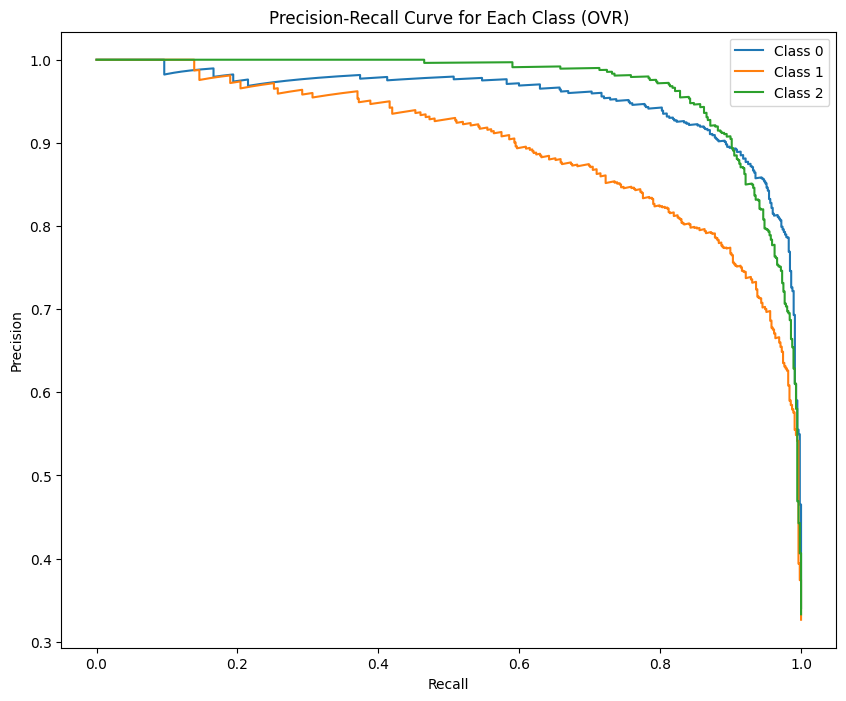

In [180]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import numpy as np

p_valid2 = cl_es.predict_proba(X_valid2)
n_classes = p_valid2.shape[1]

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    p, r, t = precision_recall_curve((y_valid2 == i).astype(int), p_valid2[:, i])
    plt.plot(r, p, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class (OVR)")
plt.legend()
plt.show()

Сравним с "однофичевым" классификатором: выберите тот признак, который, по вашему мнению, самый значимый (пока можно интуитивно выбрать)

Single best feature: registered_year
Top-5 features: [('registered_year', np.float64(29.690576574608894)), ('max_power', np.float64(23.169766127242973)), ('engine_capacity', np.float64(8.8521048032075)), ('city', np.float64(8.610409666288524)), ('mileage', np.float64(7.0083858045954335))]


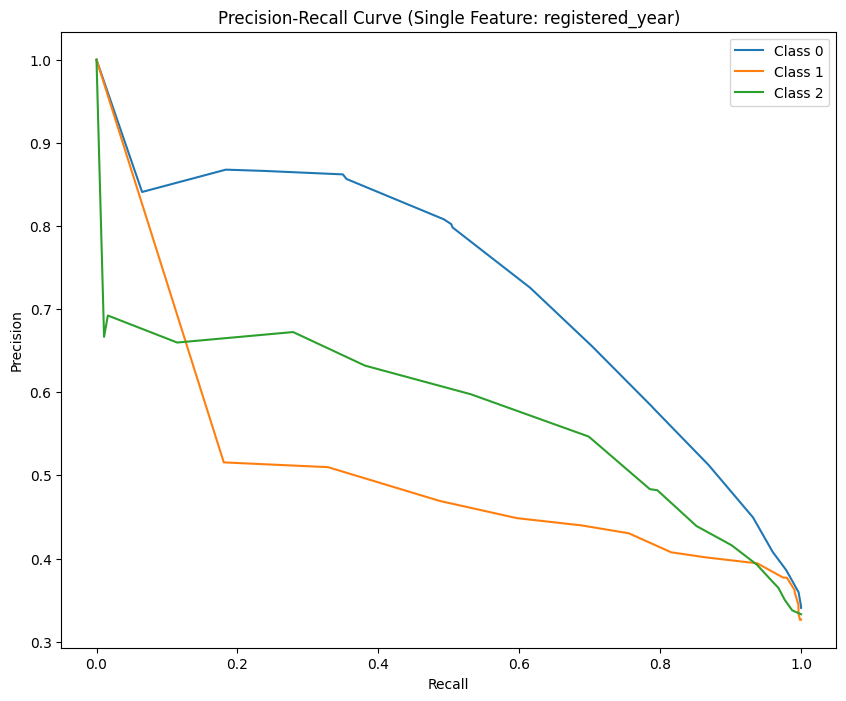

Average Precision (macro) for single-feature model: 0.5760


In [181]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
from catboost import CatBoostClassifier, Pool

# ВАЖНО: берём ту модель, которая у тебя реально есть
base_model = cl_es   # если у тебя модель называется cl, замени на cl

# 1) Выбираем самый важный признак по CatBoost
importances = base_model.get_feature_importance()
feat_imp = sorted(zip(X_train.columns, importances), key=lambda x: -x[1])

best_feature = feat_imp[0][0]
print("Single best feature:", best_feature)
print("Top-5 features:", feat_imp[:5])

# 2) Делаем однофичевые выборки
X_train_1  = X_train[[best_feature]]
X_valid1_1 = X_valid1[[best_feature]]
X_valid2_1 = X_valid2[[best_feature]]

# 3) Если признак категориальный — укажем cat_features=[0]
is_cat = str(X_train_1[best_feature].dtype) in ["category", "object"]
cat_idx_1 = [0] if is_cat else None

train_pool_1 = Pool(X_train_1, y_train, cat_features=cat_idx_1)
valid1_pool_1 = Pool(X_valid1_1, y_valid1, cat_features=cat_idx_1)

# 4) Обучаем однофичевый CatBoost
cl_one = CatBoostClassifier(
    loss_function="MultiClass",
    random_seed=42,
    verbose=0
)

cl_one.fit(
    train_pool_1,
    eval_set=valid1_pool_1,
    early_stopping_rounds=30,
    use_best_model=True,
    verbose=0
)

# 5) Вероятности на valid2
p_valid_single = cl_one.predict_proba(X_valid2_1)
n_classes = p_valid_single.shape[1]

# 6) PR-кривые
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    p, r, t = precision_recall_curve((y_valid2 == i).astype(int), p_valid_single[:, i])
    plt.plot(r, p, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (Single Feature: {best_feature})")
plt.legend()
plt.show()

# 7) Average Precision (macro) для multi-class (OVR)
y_valid2_ovr = np.eye(n_classes)[y_valid2.to_numpy()]  # one-hot
avg_precision_single = average_precision_score(y_valid2_ovr, p_valid_single, average="macro")

print(f"Average Precision (macro) for single-feature model: {avg_precision_single:.4f}")


Оценим точность и полноту, при пороге по умолчанию:

In [182]:
from sklearn.metrics import precision_score, recall_score, f1_score

model = cl_es

s_valid2 = model.predict(X_valid2).astype(int)

print("precision =", precision_score(y_valid2, s_valid2, average="micro"))
print("recall    =", recall_score(y_valid2, s_valid2, average="micro"))
print("F1        =", f1_score(y_valid2, s_valid2, average="micro"))

precision = 0.8737343656938654
recall    = 0.8737343656938654
F1        = 0.8737343656938654


Оценим возможные значения F1 при других значениях порога:


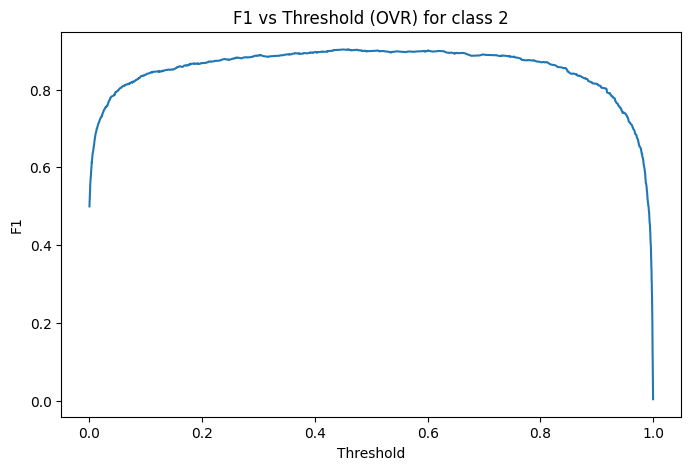

Max F1: 0.903863432165319
Best threshold: 0.459098128975956


In [183]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

model = cl_es
POS_CLASS = 2  # класс, для которого строим пороговую кривую (OVR)

# вероятности для класса POS_CLASS
proba_pos = model.predict_proba(X_valid2)[:, POS_CLASS]

# бинарная разметка: этот класс vs остальные
y_bin = (y_valid2 == POS_CLASS).astype(int)

p, r, t = precision_recall_curve(y_bin, proba_pos)

# f1 для порогов t (t на 1 меньше, чем p/r)
f1 = 2 * p[:-1] * r[:-1] / np.maximum(1e-14, (p[:-1] + r[:-1]))

plt.figure(figsize=(8, 5))
plt.plot(t, f1)
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title(f"F1 vs Threshold (OVR) for class {POS_CLASS}")
plt.show()

print("Max F1:", f1.max())
print("Best threshold:", t[np.argmax(f1)])

Есть ли закономерность: если снизить порог, то можно значительно увеличить F1?

Построим аналогичную кривую для "однофичевого" классификатора:

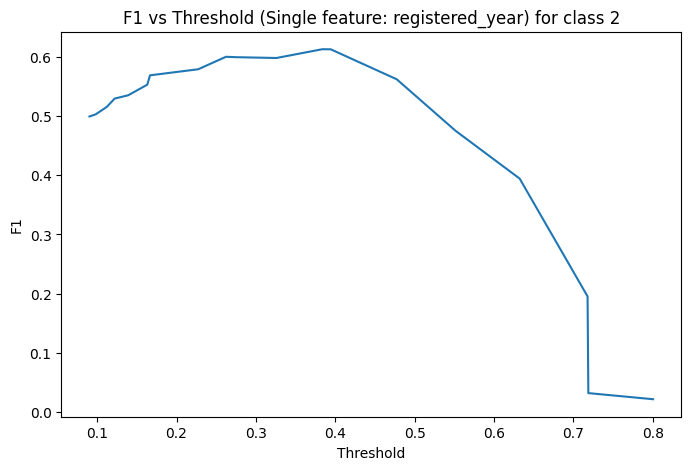

Max F1 (single feature): 0.6133333333333334
Best threshold (single feature): 0.3837169245262693


In [184]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

POS_CLASS = 2

# однофичевая выборка
X_valid2_1 = X_valid2[[best_feature]]

proba_pos_one = cl_one.predict_proba(X_valid2_1)[:, POS_CLASS]
y_bin = (y_valid2 == POS_CLASS).astype(int)

p, r, t = precision_recall_curve(y_bin, proba_pos_one)
f1 = 2 * p[:-1] * r[:-1] / np.maximum(1e-14, (p[:-1] + r[:-1]))

plt.figure(figsize=(8, 5))
plt.plot(t, f1)
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title(f"F1 vs Threshold (Single feature: {best_feature}) for class {POS_CLASS}")
plt.show()

print("Max F1 (single feature):", f1.max())
print("Best threshold (single feature):", t[np.argmax(f1)])

Все-таки Catboost обгоняет "однофичевый" классификатор :)

### Как сохранить модель

Мы обучили модель, но как ее сохранить, чтобы использовать в другой раз?

In [185]:
cl.save_model('model.cb')

In [186]:
!ls -la

total 5372
drwxr-xr-x 1 root root    4096 Dec 24 16:26  .
drwxr-xr-x 1 root root    4096 Dec 24 10:53  ..
-rw-r--r-- 1 root root 2824805 Dec 24 11:24  car_resale_prices.csv
drwxr-xr-x 5 root root    4096 Dec 24 11:08  catboost_info
drwxr-xr-x 4 root root    4096 Dec 11 14:34  .config
-rw-r--r-- 1 root root   22627 Mar  9  2023 'Mobile phone price.csv'
-rw-r--r-- 1 root root    4821 Dec 24 11:08  mobile-phone-price.zip
-rw-r--r-- 1 root root 2327580 Dec 24 16:26  model.cb
drwxr-xr-x 1 root root    4096 Dec 11 14:34  sample_data
-rw-r--r-- 1 root root  289533 Oct 28  2023  used_cars_UK.csv


In [187]:
cl2 = CatBoostClassifier()
cl2.load_model('model.cb')

Проверим как работает загруженный классификатор на валидационной выборке:

In [188]:
roc_auc_score(y_valid2, cl2.predict_proba(X_valid2), multi_class='ovr')

np.float64(0.971304136453202)

Важность признаков:

In [189]:
sorted(zip(X_train.columns, cl.get_feature_importance()), key=lambda x: -x[1])

[('registered_year', np.float64(25.328504594469017)),
 ('max_power', np.float64(20.458545050058444)),
 ('city', np.float64(11.512075715805153)),
 ('mileage', np.float64(8.34519969514578)),
 ('engine_capacity', np.float64(8.082522285510361)),
 ('body_type', np.float64(6.881391900094816)),
 ('kms_driven', np.float64(5.952822842036994)),
 ('insurance', np.float64(4.32157159233221)),
 ('transmission_type', np.float64(3.052850837390304)),
 ('fuel_type', np.float64(2.8747392387932926)),
 ('owner_type', np.float64(2.4446866303834414)),
 ('seats', np.float64(0.7450896179802181))]

Проверим, сохраняется ли важность признаков в файле модели:

In [190]:
cl2.get_feature_importance()

array([25.32850459,  8.08252229,  5.95282284, 20.45854505,  0.74508962,
        8.3451997 ,  4.32157159,  3.05285084,  2.44468663,  2.87473924,
        6.8813919 , 11.51207572])

А названия признаков сохраняются в файле?

In [191]:
cl2.feature_names_

['registered_year',
 'engine_capacity',
 'kms_driven',
 'max_power',
 'seats',
 'mileage',
 'insurance',
 'transmission_type',
 'owner_type',
 'fuel_type',
 'body_type',
 'city']

Количество деревьев в модели:

In [192]:
cl.tree_count_, cl2.tree_count_

(998, 998)

### Конвертация модели

Как использовать модель не из Python или из Python, но без Catboost?

Сохранить в [ONNX](https://ru.wikipedia.org/wiki/ONNX):

In [193]:
cl.save_model(
    "model.onnx",
    format="onnx",
    export_parameters={
        'onnx_model_version': 1,
        'onnx_doc_string': 'test model for BinaryClassification',
        'onnx_graph_name': 'CatBoostModel_for_BinaryClassification'
    }
)

CatBoostError: catboost/libs/model/model_export/model_exporter.cpp:96: ONNX-ML format export does yet not support categorical features

In [ ]:
!ls -la

In [ ]:
!head -20 model.onnx

Сохранение модели в формате [PMML](https://ru.wikipedia.org/wiki/%D0%AF%D0%B7%D1%8B%D0%BA_%D1%80%D0%B0%D0%B7%D0%BC%D0%B5%D1%82%D0%BA%D0%B8_%D0%BF%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F):

In [ ]:
cl.save_model(
    "model.pmml",
    format="pmml",
    export_parameters={
        'pmml_description': 'test model for BinaryClassification',
        'pmml_model_version': '1'
    }
)

In [ ]:
!ls -la

PMML - это текстовый файл в формате XML:

In [ ]:
!head -50 model.pmml
!echo "..."
!tail -50 model.pmml

А можем ли конвертировать модель в свой формат или сформировать код функции скоринга на каком-либо языке программирования? Да!

Структура дерева:

In [ ]:
cl.plot_tree(tree_idx=0, pool=X_train)

Как добраться до структуры деревьев программно:
- https://medium.com/@joachimiak.krzysztof/extracting-trees-from-gbm-models-as-data-frames-ce37f4c08ba6

### Как интерпретировать предсказания модели

Как можно объяснить почему модель выдала тот или иной результат? Используем SHAP



In [ ]:
!pip install shap

In [ ]:
import shap

explainer = shap.TreeExplainer(cl)
shap_values = explainer(X_valid2)

Оценим результат прогноза на первом объекте:

In [ ]:
shap.plots.waterfall(shap_values[0])
p_valid2[0]

Оценим результат прогноза на втором объекте:

In [ ]:
shap.plots.waterfall(shap_values[1])
p_valid2[1]

### Что еще стоит знать о Catboost?

### Работа с категориальными признаками

Он поддерживает работу с категориальными (cat) признаками без предварительной обработки, достаточно указать какие именно признаки являются в наборе данных категориальными.


### Обработка пропущенных значений

https://catboost.ai/en/docs/concepts/algorithm-missing-values-processing

Пропущенные значения заменяются на минимальные или максимальные в зависимости от настроек.


---



Рассмотрим реализацию градиентного бустинга над деревьями в других библиотеках.

### Scikit-learn



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

sk_gb_cl = GradientBoostingClassifier()
sk_gb_cl.fit(X_train, y_train)

roc_auc_score(y_valid2, sk_gb_cl.predict_proba(X_valid2)[:,1])

Медленно работает.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

sk_hgb_cl = HistGradientBoostingClassifier()
sk_hgb_cl.fit(X_train, y_train)

roc_auc_score(y_valid2, sk_hgb_cl.predict_proba(X_valid2)[:,1])

Гораздо быстрее отработал. Ускорение достигается за счет использования гистограмм.

### LightGBM


In [ ]:
import lightgbm

lgbm_cl = lightgbm.LGBMClassifier()
lgbm_cl.fit(X_train, y_train)

roc_auc_score(y_valid2, lgbm_cl.predict_proba(X_valid2)[:,1])

Визуализируем первое дерево модели и рассмотрим отличия от Catboost:

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(40, 40))
lightgbm.plot_tree(lgbm_cl, tree_index=0,dpi=200, ax=ax)
plt.show()

Первое что можно заметить - ветви дерева разные по высоте (глубине).

Поэтому для LightGBM важную роль в обучении модели играет гиперпараметр num_leaves.



### Xgboost

In [ ]:
import xgboost

xgb_cl = xgboost.XGBClassifier()
xgb_cl.fit(X_train, y_train)

roc_auc_score(y_valid2, xgb_cl.predict_proba(X_valid2)[:,1])

In [ ]:
fig, ax = plt.subplots(figsize=(30, 30))
xgboost.plot_tree(xgb_cl, num_trees=0, rankdir='LR', ax=ax)
plt.show()